In [5]:
#Libraries

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

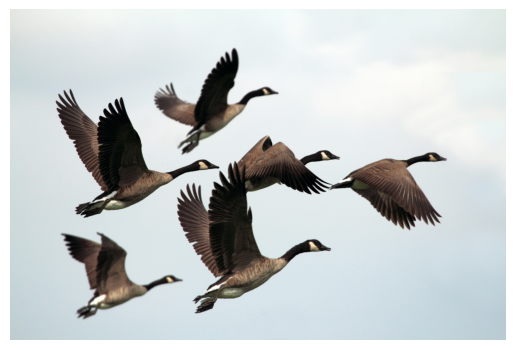

In [6]:
#Reading and displaying the images

#Image 1

car = imread('/content/Bird.jpg')
car.size , car.shape
plt.imshow(car)
plt.axis('off')
plt.show()


#Image 2

# car = imread('/images/Car.jpg')
# car.size , car.shape
# #plt.imshow(car)


#Image 3

# tree = imread('/images/Tree.jpg')
# tree.size , tree.shape
# #plt.imshow(tree)

In [7]:
#Converting the 3 2d matrics into 3 1D matrices
height , width , channel = car.shape
car_flat = car.reshape(height * width , channel)
car_flat.shape


(17915904, 3)

In [8]:
#Functions for later use


#Not used yet in any code
def distance(p , q , array):

  diff = (array[p] - array[q])
  summed_sq = np.sum(diff ** 2)
  dist = (summed_sq ** 0.5 )
  return dist



#test
# distance(0,1,car_flat)
# car_flat[0:2]

def centroid_select(array , k):

  centroid_indices = np.random.choice(array.shape[0] , k)
  return array[centroid_indices]

#test
#centroid_select(car_flat , 5)


def vectorisation_distance(ExpandedArray1 , ExpandedArray2):

  diff = ExpandedArray1 - ExpandedArray2

  # Axis 2 because colour channel is along axis 2 as seen after this block
  dist = (np.sum(diff ** 2 , axis = 2) ** 0.5 )

  return dist

def shift(current_centroids , new_centroids):
  sq_dif = (current_centroids - new_centroids)**2
  sum_sq = np.sum(sq_dif)
  return sum_sq



In [9]:
# Since the size number of pixels is huge we cannot run loops to find distance using normal function so we use
# vectoristion distance function

k = int(input("Enter number of clusters"))
iterations = int(input("Enter number of iterations"))
print(centroid_select(car_flat , k).shape)
print(car_flat.shape)


# The shapes are different so we cannot subtract directly and so we add an axis to both of the arrays and then
# we can subtract them so the arrays stretch to fit so we can find the difference and then the distance

# The pixel array is of shape ( n , 3 ) and the centroid array is ( k , 3 ) we want to add axis and
# stretch it to ( n , k , 3) or ( k , n , 3 ) to be able to subtract one from the other lets choose (n , k , 3 )
print('Expanded Sizes')
car_expanded  = car_flat[: , np.newaxis , :]
print(car_expanded.shape)
centroid_expanded = centroid_select(car_flat , k)[np.newaxis , : , :]
print(centroid_expanded.shape)

# Now we can find distance
dif = car_expanded - centroid_expanded
print(dif.shape)
# Its size is n , k , 3 as expected but we cant use the  normal distance formula we created anymore so
# use the vectorisationdistance function
distances = vectorisation_distance(car_expanded , centroid_expanded)
print(distances.shape)

# Now we have the distance of each pixel from the centroid of the cluster
# Now we calculate from which cluster centroid is the pixel closest to

cluster_centroid_closest = np.argmin(distances , axis = 1)


#test
#cluster_centroid_closest[0:10]







Enter number of clusters3
Enter number of iterations15
(3, 3)
(17915904, 3)
Expanded Sizes
(17915904, 1, 3)
(1, 3, 3)
(17915904, 3, 3)
(17915904, 3)


In [10]:
#Lets iteratively improve the clusters

# Initalise the centroids which we have calculated in abov block
current_centroids = centroid_expanded[0]
iter = 0
#The loop will run till the previous iteration and latest itertion centroids are same
while True:
  iter +=1

  centroid_expanded = current_centroids[np.newaxis , : , :]

  distances = vectorisation_distance(car_expanded , centroid_expanded)

  cluster_centroid_closest = np.argmin(distances , axis = 1)

  #Now calculating the new centroids for this round
  new_centroid_list = []

  for j in range(k):

    cluster_pixels = car_flat[cluster_centroid_closest == j]

    new_centroid = np.mean(cluster_pixels , axis = 0)

    new_centroid_list.append(new_centroid)

  new_centroids = np.array(new_centroid_list)

  # if shift(current_centroids , new_centroids) <= 0.001:
  #   break

  current_centroids = new_centroids

  if iter == iterations:
    break



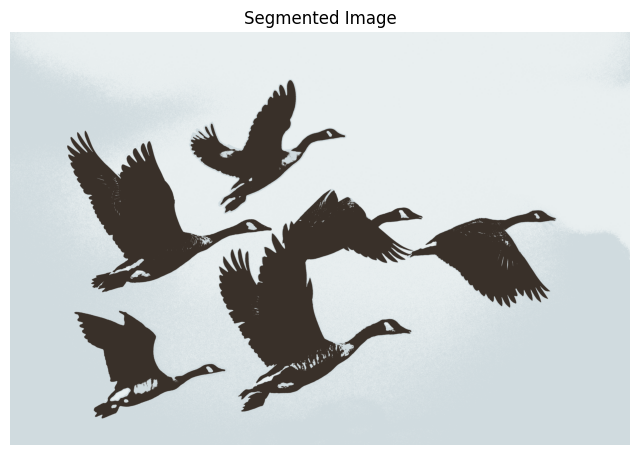

In [11]:
# Now lets make the picture back to it original dimension and see all the clusters


correct_colors = np.uint8(current_centroids)
#First make the flat segmented image
segmented_flat = correct_colors[cluster_centroid_closest]

#Make it 2d
segmented_image = segmented_flat.reshape(car.shape)

#Now lets see it displayed
plt.figure(figsize=(8, 6))
plt.title("Segmented Image")
plt.imshow(segmented_image)
plt.axis('off')
plt.show()



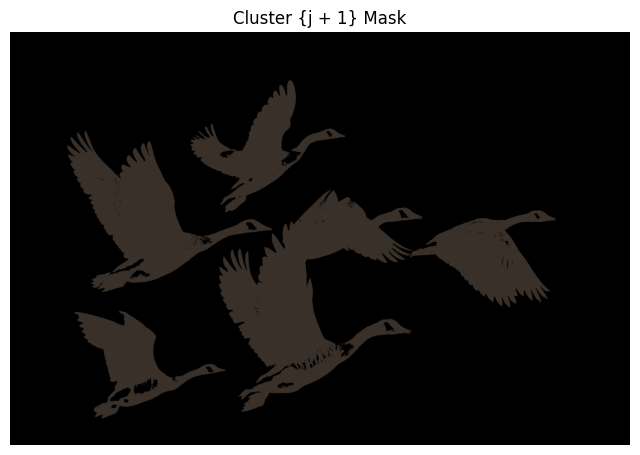

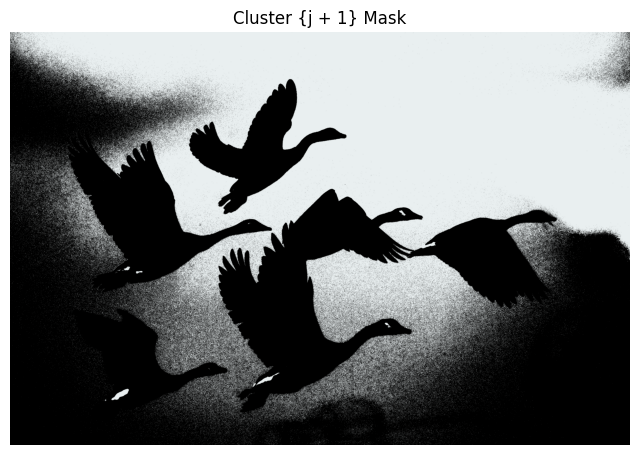

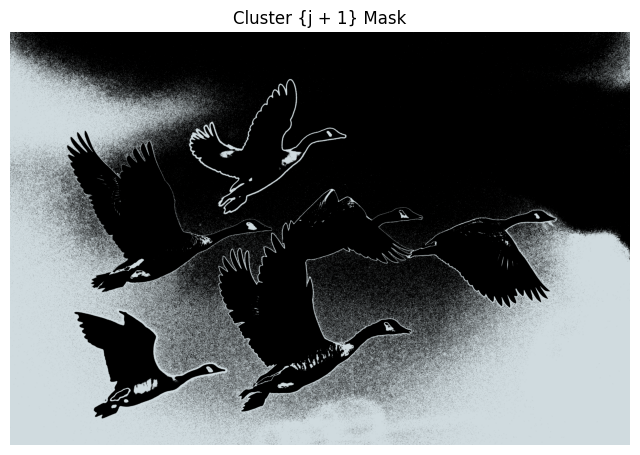

In [12]:
# Making different masks for different clusters

# Logic used is make the rest of pixels black and the pixels inside the cluster coloured as is

for j in range(k):


  cluster_mask_flat = np.copy(car_flat)

  cluster_mask_flat[cluster_centroid_closest == j] = correct_colors[j]


  cluster_mask_flat[cluster_centroid_closest != j] = [0, 0, 0]


  cluster_mask_image = cluster_mask_flat.reshape(car.shape)


  plt.figure(figsize=(8, 6))
  plt.title("Cluster {j + 1} Mask")
  plt.imshow(cluster_mask_image)
  plt.axis('off')
  plt.show()








What are the numbers of mask for foreground give space separated2


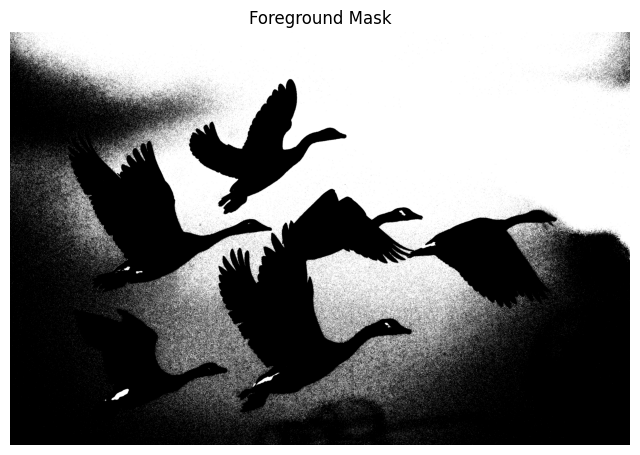

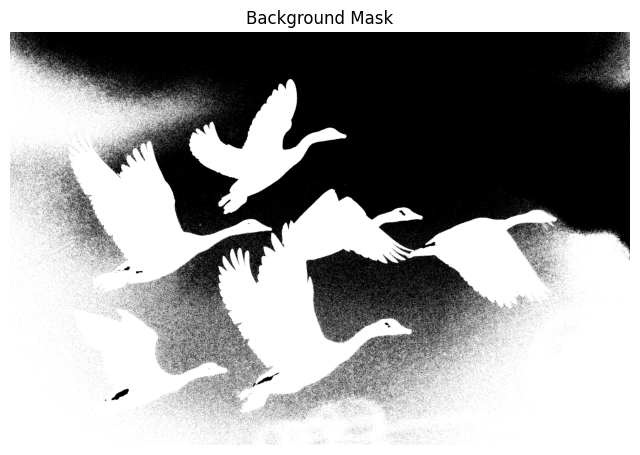

In [13]:
#Merging some masks to separate the foreground and background image

#Asking the masks numbers which can be selected by looking at the above images the number of inputs is not fixed so any
#k value can work

k_values_foreground = list(map(int, input("What are the numbers of mask for foreground give space separated").split()))

actual_indices = [i - 1 for i in k_values_foreground]

foreground_flat = np.isin(cluster_centroid_closest , actual_indices)


image_height = car.shape[0]
image_width  = car.shape[1]

foreground_actual = foreground_flat.reshape(image_height , image_width)

foreground_actual = foreground_actual.astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.title("Foreground Mask")
plt.imshow(foreground_actual, cmap='gray')
plt.axis('off')
plt.show()

#Doing the same thing for background images
background_indices = [i for i in  range(k)if i not in actual_indices]


background_flat = np.isin(cluster_centroid_closest , background_indices)


image_height = car.shape[0]
image_width  = car.shape[1]

background_actual = background_flat.reshape(image_height , image_width)

foreground_actual = foreground_actual.astype(np.uint8)

plt.figure(figsize=(8, 6))
plt.title("Background Mask")
plt.imshow(background_actual , cmap='gray')
plt.axis('off')
plt.show()

